# 🇻🇳 Transfer Learning — TFT v3 → Vietnam (NO Economic Features)

**Chiến lược:** Load pretrained TFT → Fine-tune trên dữ liệu VN, nhưng **BỎ các biến kinh tế**.

---

### So sánh với các phiên bản khác:

| Phiên bản | Transfer | Biến kinh tế | Ghi chú |
|---|---|---|---|
| No TL | ❌ | ✅ | transfer_learning_v3_no_tl.ipynb |
| **TL + No Econ** | ✅ | ❌ | **File này** — TL thuần weather |
| TL + Econ | ✅ | ✅ | transfer_learning_v3.ipynb — full version |

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, shutil, copy
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

torch.serialization.add_safe_globals([GroupNormalizer, QuantileLoss])

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'.')
VN_DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
PRETRAIN_CKPT  = BASE_DIR / 'checkpoint' / 'tft_v3_best.ckpt'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'tft_vn_v3_tl_no_econ'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data : {VN_DATA_PATH}')
print(f'Pretrain: {PRETRAIN_CKPT}')
print(f'Exists  : {PRETRAIN_CKPT.exists()}')

PyTorch : 2.9.1+cu126
Device  : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
VN data : data\processed\VN_data\vn_tft_ready.csv
Pretrain: checkpoint\tft_v3_best.ckpt
Exists  : True


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Transfer Learning - BỎ biến kinh tế)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    max_encoder_length    = 18,
    max_prediction_length = 6,
    min_series_length     = 24,

    # ── NO ECONOMIC VARS ──────────────────────────────────────────────────
    economic_vars = [],  # EMPTY — không dùng biến kinh tế

    val_cutoff_months     = 12,

    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.2,
    hidden_continuous_size= 32,
    lstm_layers           = 2,
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── Phase 1: Frozen LSTM ──────────────────────────────────────────────
    phase1_lr             = 1e-3,
    phase1_epochs         = 15,
    phase1_patience       = 6,

    # ── Phase 2: Full fine-tune ───────────────────────────────────────────
    phase2_lr             = 3e-5,
    phase2_epochs         = 40,
    phase2_patience       = 10,

    batch_size            = 32,
    gradient_clip_val     = 0.1,
    num_workers           = 0,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config VN Transfer Learning (NO Economic Features):')
print(f'  Phase 1 LR: {CFG["phase1_lr"]:.0e}')
print(f'  Phase 2 LR: {CFG["phase2_lr"]:.0e}')
print(f'  Economic vars: {len(CFG["economic_vars"])} (NONE)')

INFO: Seed set to 42


[09:43:32] INFO     Seed set to 42                                   seed.py:57
Config VN Transfer Learning (NO Economic Features):
  Phase 1 LR: 1e-03
  Phase 2 LR: 3e-05
  Economic vars: 0 (NONE)


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA (BỎ qua lag cho economic_vars)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')

FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()
print(f'After filter: {df.shape}')

mu  = df.groupby('entity')['precipitation'].transform('mean')
std = df.groupby('entity')['precipitation'].transform('std').replace(0, 1)
df['prec_zscore'] = (df['precipitation'] - mu) / std

df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df.groupby(['entity', 'series'])[num_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# ── BỎ lag cho economic_vars (vì không dùng) ──────────────────────────────
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Raw VN shape: (432, 30)
After filter: (360, 30)
Date range: 2019-01-01 → 2024-12-01


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — FEATURES (BỎ economic_vars)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STATIC_CATEGORICALS = ['entity']

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'is_dry_season', 'is_flood_season',
    'quarter_sin', 'quarter_cos',
]

TIME_VARYING_UNKNOWN_REALS = [
    'temperature', 'solar', 'humidity', 'precipitation',
    'log_precipitation', 'prec_zscore', 'temp_anomaly', 'solar_norm',
    'humidity_anomaly', 'prec_lag_1', 'prec_lag_2', 'precip_roll6',
    # ── BỎ: IPI_Value, CPI_Value, GDP_trillion, Oil_Price, FDI_disbursed, gas_price, castlecoal_price ──
]

if 'precip_roll6' not in df.columns and 'prec_roll_3' in df.columns:
    df['precip_roll6'] = df['prec_roll_3']

TIME_VARYING_KNOWN_REALS   = [c for c in TIME_VARYING_KNOWN_REALS   if c in df.columns]
TIME_VARYING_UNKNOWN_REALS = [c for c in TIME_VARYING_UNKNOWN_REALS if c in df.columns]

print(f'Features: {len(TIME_VARYING_UNKNOWN_REALS)} unknown_reals (weather only, NO economic)')

training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
print(f'Train/Val split: {(df["time_idx"]<=training_cutoff).sum()} / {(df["time_idx"]>training_cutoff).sum()}')

Features: 6 unknown_reals (weather only, NO economic)
Train/Val split: 300 / 60


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('\nCreating TimeSeriesDataSet...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Training samples  : {len(training_vn):,}')
print(f'Validation samples: {len(validation_vn):,}')

train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 4, num_workers=CFG['num_workers']
)


Creating TimeSeriesDataSet...


Training samples  : 325
Validation samples: 5


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — BUILD & LOAD PRETRAINED
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
vn_model = TemporalFusionTransformer.from_dataset(
    training_vn,
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    learning_rate          = CFG['phase1_lr'],
    optimizer              = 'adamw',
    log_interval           = 5,
)

n_params_vn = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'VN model parameters: {n_params_vn:,} ({n_params_vn/1e6:.2f}M)')

if PRETRAIN_CKPT.exists():
    pretrained_ckpt = torch.load(str(PRETRAIN_CKPT), map_location='cpu', weights_only=False)
    pretrained_state = pretrained_ckpt['state_dict']
    vn_state = vn_model.state_dict()
    transferred = []
    for name, param in pretrained_state.items():
        if name in vn_state and vn_state[name].shape == param.shape:
            vn_state[name].copy_(param)
            transferred.append(name)
    vn_model.load_state_dict(vn_state)
    print(f'Transferred weights: {len(transferred)}')
else:
    print('Pretrained checkpoint not found!')

VN model parameters: 1,284,056 (1.28M)
Transferred weights: 338


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: FREEZE LSTM + ATTENTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def freeze_encoder_layers(model):
    frozen = []
    for name, param in model.named_parameters():
        if any(keyword in name for keyword in
               ['lstm_encoder', 'multihead_attn', 'self_attn', 'attention']):
            param.requires_grad = False
            frozen.append(name)
    return frozen

frozen_layers = freeze_encoder_layers(vn_model)
trainable_p1 = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
total_params  = sum(p.numel() for p in vn_model.parameters())

print(f'Phase 1 — Frozen LSTM + Attention:')
print(f'  Trainable: {trainable_p1:,} / {total_params:,} ({trainable_p1/total_params*100:.1f}%)')

vn_model.hparams.learning_rate = CFG['phase1_lr']

ckpt_p1 = ModelCheckpoint(
    dirpath=str(CKPT_DIR), filename='vn_phase1_no_econ_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, save_last=False
)
es_p1 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase1_patience'], mode='min', verbose=True
)

trainer_p1 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase1_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p1, es_p1],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase1_no_econ'),
    enable_progress_bar = True,
    precision         = '32',
)

print(f'\nPhase 1: epochs={CFG["phase1_epochs"]}, patience={CFG["phase1_patience"]}')
vn_model.train()
trainer_p1.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Phase 1 done! Best val_loss = {ckpt_p1.best_model_score:.6f}')

Phase 1 — Frozen LSTM + Attention:
  Trainable: 978,616 / 1,284,056 (76.2%)


INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

INFO: Metric val_loss improved by 0.151 >= min_delta = 0.0. New best score: 0.680


[09:43:48] INFO     Metric val_loss improved by 0.151 >=  early_stopping.py:305
                    min_delta = 0.0. New best score:                           
                    0.680                                                      


INFO: Monitored metric val_loss did not improve in the last 6 records. Best score: 0.680. Signaling Trainer to stop.


[09:44:04] INFO     Monitored metric val_loss did not     early_stopping.py:305
                    improve in the last 6 records. Best                        
                    score: 0.680. Signaling Trainer to                         
                    stop.                                                      


Phase 1 done! Best val_loss = 0.680325


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: UNFREEZE + FULL FINE-TUNE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_p1_path = ckpt_p1.best_model_path
with torch.serialization.safe_globals([GroupNormalizer, QuantileLoss]):
    vn_model_p2 = TemporalFusionTransformer.load_from_checkpoint(best_p1_path)

for param in vn_model_p2.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in vn_model_p2.parameters() if p.requires_grad)
print(f'Phase 2 — Full fine-tune:')
print(f'  Trainable: {trainable_p2:,} (100%)')

vn_model_p2.hparams.learning_rate = CFG['phase2_lr']

ckpt_p2 = ModelCheckpoint(
    dirpath  = str(CKPT_DIR),
    filename = 'tft_vn_v3_tl_no_econ_{epoch:02d}_{val_loss:.4f}',
    monitor  = 'val_loss',
    mode     = 'min',
    save_top_k = 3,
    save_last  = True,
)
es_p2 = EarlyStopping(
    monitor='val_loss', patience=CFG['phase2_patience'], mode='min', verbose=True
)

trainer_p2 = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['phase2_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt_p2, es_p2],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='vn_phase2_no_econ'),
    enable_progress_bar = True,
    precision         = '32',
)

print(f'\nPhase 2: epochs={CFG["phase2_epochs"]}, patience={CFG["phase2_patience"]}')
vn_model_p2.train()
trainer_p2.fit(vn_model_p2, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Phase 2 done! Best val_loss = {ckpt_p2.best_model_score:.6f}')

INFO: GPU available: True (cuda), used: True


Phase 2 — Full fine-tune:
  Trainable: 1,284,056 (100%)
[09:44:06] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO: Metric val_loss improved by 0.018 >= min_delta = 0.0. New best score: 0.640


[09:44:23] INFO     Metric val_loss improved by 0.018 >=  early_stopping.py:305
                    min_delta = 0.0. New best score:                           
                    0.640                                                      


INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.640. Signaling Trainer to stop.


[09:44:47] INFO     Monitored metric val_loss did not     early_stopping.py:305
                    improve in the last 10 records. Best                       
                    score: 0.640. Signaling Trainer to                         
                    stop.                                                      


Phase 2 done! Best val_loss = 0.639688


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — SAVE CHECKPOINT & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL_CKPT = CKPT_DIR / 'tft_vn_v3_tl_no_econ_best.ckpt'

if os.path.exists(ckpt_p2.best_model_path):
    shutil.copy2(ckpt_p2.best_model_path, FINAL_CKPT)
    print(f'Saved: {FINAL_CKPT}')

config = {
    'version'                   : 'tft_vn_v3_tl_no_econ',
    'pretrained_from'           : str(PRETRAIN_CKPT),
    'transfer_learning'         : True,
    'economic_features'         : False,  # KEY DIFFERENCE
    'best_ckpt'                 : str(FINAL_CKPT),
    'best_val_loss'             : float(ckpt_p2.best_model_score),
    'phase1_val_loss'           : float(ckpt_p1.best_model_score),
    'hidden_size'               : CFG['hidden_size'],
}

cfg_path = CKPT_DIR / 'tft_vn_v3_tl_no_econ_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)
print(f'Config: {cfg_path}')

Saved: checkpoint\tft_vn_v3_tl_no_econ_best.ckpt
Config: checkpoint\tft_vn_v3_tl_no_econ_config.json


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — EVALUATION METRICS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with torch.serialization.safe_globals([GroupNormalizer, QuantileLoss]):
    best_model = TemporalFusionTransformer.load_from_checkpoint(str(FINAL_CKPT))
best_model.eval()

# Dự báo trên toàn bộ chuỗi để có prediction cho cả train/val/test
full_dataset = TimeSeriesDataSet.from_dataset(
    training_vn,
    df,
    stop_randomization=True
)
full_loader = full_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)
raw_preds = best_model.predict(full_loader, mode='raw', return_x=True, return_index=True)
point_preds = best_model.predict(val_loader, mode='prediction', return_x=True)
pred_vals = point_preds.output

actuals = torch.cat([y[0] for _, y in val_loader])

mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2*(actuals - pred_vals).abs() / (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = ((actuals - pred_vals).abs().sum() / (actuals.abs().sum() + 1e-8)).item() * 100
r2 = (1 - ((actuals - pred_vals) ** 2).sum() / ((actuals - actuals.mean()) ** 2).sum()).item()

print(f'\n📊 Validation Metrics (Transfer Learning — NO Economic Features):')
print(f'  MAE   : {mae:.4f} TWh')
print(f'  RMSE  : {rmse:.4f} TWh')
print(f'  R2    : {r2:.4f}')
print(f'  SMAPE : {smape:.2f}%')
print(f'  WAPE  : {wape:.2f}%')

INFO: GPU available: True (cuda), used: True


[09:48:36] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61

📊 Validation Metrics (Transfer Learning — NO Economic Features):
  MAE   : 0.8542 TWh
  RMSE  : 1.3859 TWh
  R2    : 0.9100
  SMAPE : 17.76%
  WAPE  : 16.00%


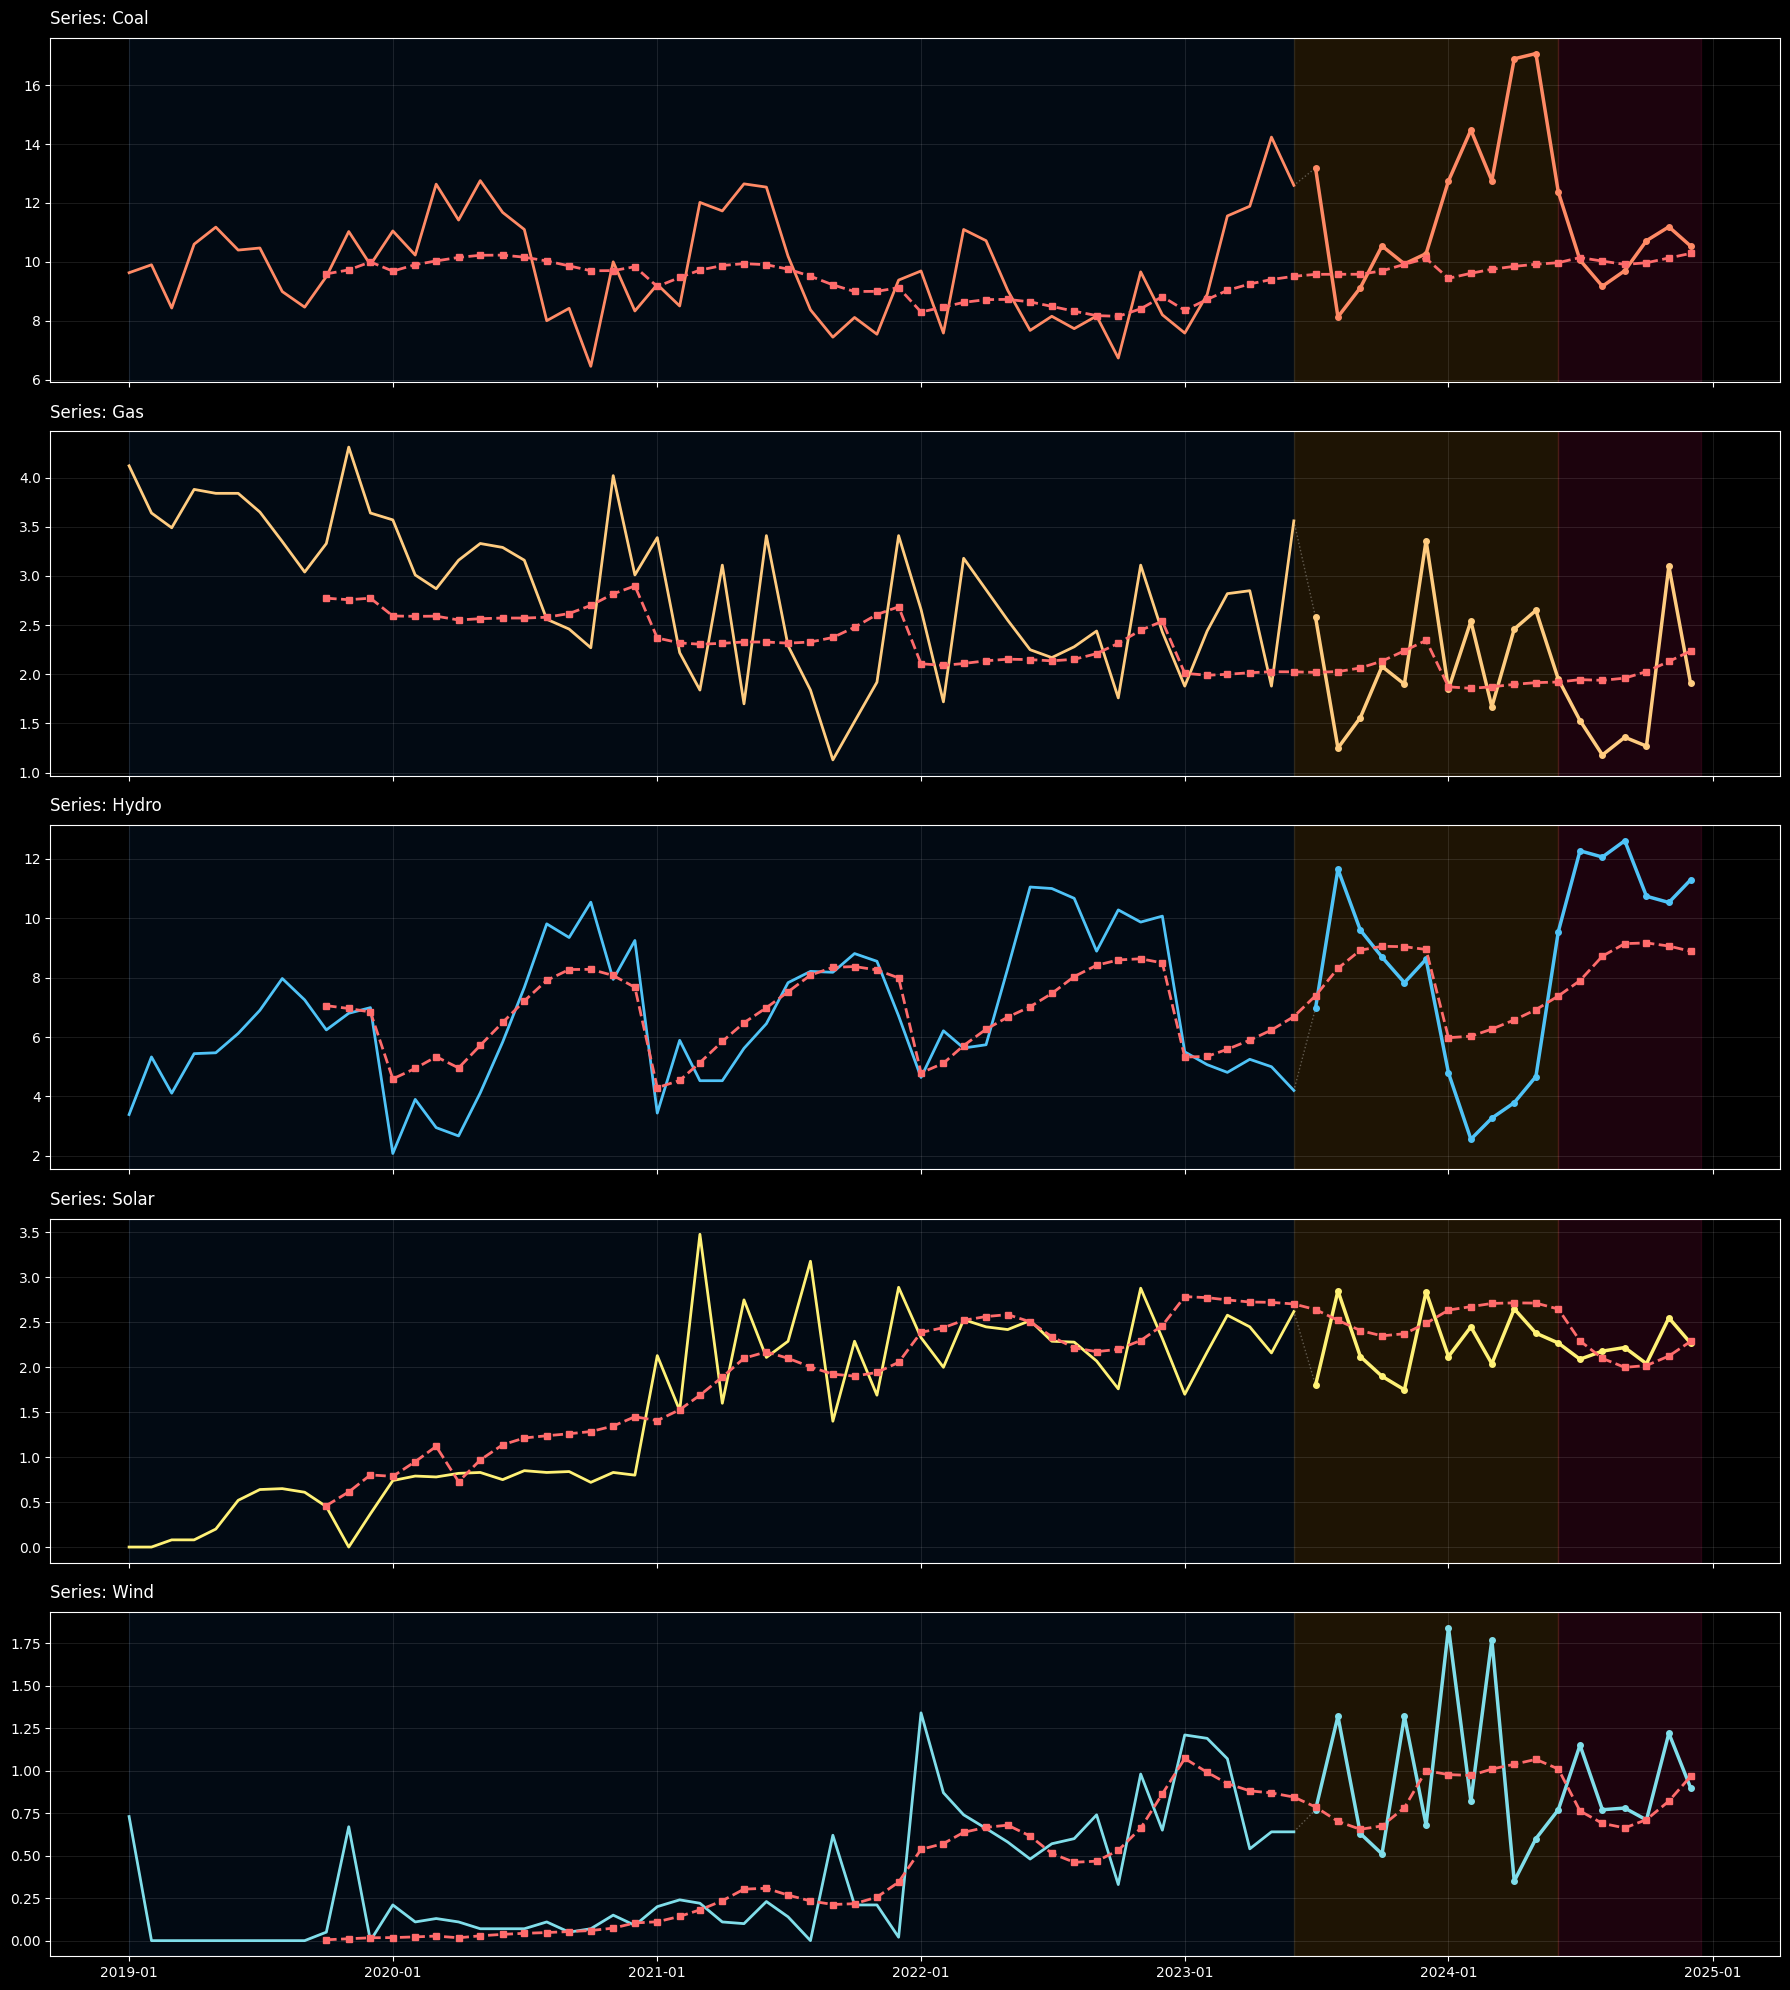

In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — VISUALIZATION: TRAIN/VAL/TEST SPLIT WITH PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

plt.style.use('dark_background')

SERIES_COLORS = {
    'Coal': '#ff8a65', 'Gas': '#ffcc80',
    'Hydro': '#4fc3f7', 'Solar': '#fff176', 'Wind': '#80deea',
}

TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END   = pd.Timestamp('2024-06-01')
TEST_END  = df['date'].max()

# ── Map time_idx -> date theo tung series để can chinh decoder ───────────────
time_map = df[['entity', 'series', 'time_idx', 'date']].drop_duplicates()
time_map['time_idx'] = time_map['time_idx'].astype(int)

# ── Helper: đưa tensor về CPU trước khi đổi sang NumPy ──────────────────────
def to_cpu_numpy(obj):
    if hasattr(obj, 'prediction'):
        obj = obj.prediction
    if torch.is_tensor(obj):
        return obj.detach().cpu().numpy()
    if isinstance(obj, dict):
        return {key: to_cpu_numpy(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_cpu_numpy(value) for value in obj]
    return np.asarray(obj)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — VISUALIZATION: FIXED OVERLAPPING PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch

# --- Giữ nguyên các hàm bổ trợ an toàn từ bước trước ---
def ensure_numpy(data):
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()
    if isinstance(data, (list, tuple)):
        return [ensure_numpy(x) for x in data]
    return data

# --- Xử lý dữ liệu dự báo ---
raw_output = raw_preds.output
if isinstance(raw_output, (list, tuple)):
    pred_out = ensure_numpy(raw_output[0])
else:
    pred_out = ensure_numpy(raw_output)

if isinstance(pred_out, np.ndarray):
    if pred_out.ndim == 3: # Lấy median quantile
        pred_out = pred_out[:, :, 2]
    elif pred_out.ndim == 1:
        pred_out = pred_out.reshape(-1, 1)

decoder_time_idx = ensure_numpy(raw_preds.x['decoder_time_idx'])
decoder_target = ensure_numpy(raw_preds.x['decoder_target'])

# Chuyển list thành array nếu cần (xử lý lỗi inhomogeneous từ bước trước)
if isinstance(decoder_time_idx, list): decoder_time_idx = np.concatenate(decoder_time_idx, axis=0)
if isinstance(decoder_target, list): decoder_target = np.concatenate(decoder_target, axis=0)
if isinstance(pred_out, list): pred_out = np.concatenate(pred_out, axis=0)

pred_rows = []
for i in range(len(pred_out)):
    row = raw_preds.index.iloc[i]
    pred_rows.append(pd.DataFrame({
        'entity': row.get('entity', None),
        'series': row.get('series', None),
        'time_idx': decoder_time_idx[i].astype(int),
        'pred': pred_out[i],
        'actual': decoder_target[i],
    }))

pred_df = pd.concat(pred_rows, ignore_index=True)

# 🔥 FIX CHÍNH Ở ĐÂY: Gom nhóm để mỗi thời điểm chỉ còn 1 giá trị dự báo duy nhất
# Điều này sẽ loại bỏ các đường "spaghetti" chồng chéo
pred_df = pred_df.groupby(['entity', 'series', 'time_idx'], as_index=False).agg({
    'pred': 'mean',   # Lấy trung bình các dự báo cho cùng 1 thời điểm
    'actual': 'first' # Thực tế thì giống nhau nên lấy cái đầu tiên
})

# Merge với map thời gian
pred_df = pred_df.merge(time_map, on=['entity', 'series', 'time_idx'], how='left')

# --- Phần vẽ biểu đồ (Giữ nguyên cấu trúc của bạn) ---
fig, axes = plt.subplots(
    len(FINE_TUNE_SERIES), 1,
    figsize=(18, 4 * len(FINE_TUNE_SERIES)),
    sharex=True, facecolor='#000000'
)
if len(FINE_TUNE_SERIES) == 1: axes = [axes]

for ax, ser in zip(axes, FINE_TUNE_SERIES):
    sub = df[df['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#cccccc')
    ax.set_facecolor('#000000')
    
    # Vẽ vùng Train/Val/Test
    ax.axvspan(sub['date'].min(), TRAIN_END, alpha=0.1, color='#1565c0')
    ax.axvspan(TRAIN_END, VAL_END, alpha=0.12, color='#f9a825')
    ax.axvspan(VAL_END, TEST_END + pd.DateOffset(days=15), alpha=0.15, color='#c2185b')
    
    # Vẽ thực tế
    ax.plot(sub['date'], sub['generation_TWh'], color='white', linewidth=1, alpha=0.3, linestyle=':', label='Actual (Full)')
    
    train_sub = sub[sub['date'] <= TRAIN_END]
    ax.plot(train_sub['date'], train_sub['generation_TWh'], color=color, linewidth=2, label='Train (Actual)')
    
    val_test_sub = sub[sub['date'] > TRAIN_END]
    ax.plot(val_test_sub['date'], val_test_sub['generation_TWh'], color=color, linewidth=2.5, marker='o', markersize=4)

    # Vẽ dự báo (Bây giờ đường sẽ mượt và duy nhất)
    pred_sub = pred_df[(pred_df['series'] == ser) & pred_df['date'].notna()].sort_values('date')
    if not pred_sub.empty:
        ax.plot(pred_sub['date'], pred_sub['pred'],
                color='#ff6b6b', linewidth=2, marker='s', markersize=4, 
                label='Predicted (Mean)', linestyle='--')

    # Định dạng trục
    ax.set_title(f"Series: {ser}", color='white', loc='left', pad=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

📊 FEATURE IMPORTANCE — Transfer Learning (NO Economic Features)

  Aligned importance from 11 to 10 features
Top 15 Most Important Encoder Variables:
────────────────────────────────────────────────────────────
 1. series                         █████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 19.48%
 2. month                          █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 11.37%
 3. time_idx                       █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 11.27%
 4. precipitation                  █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 10.94%
 5. prec_zscore                    █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 10.06%
 6. temperature                    ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  8.97%
 7. humidity                       ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  8.83%
 8. year                           ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  8.43%
 9. solar                          ███░░░░░░░

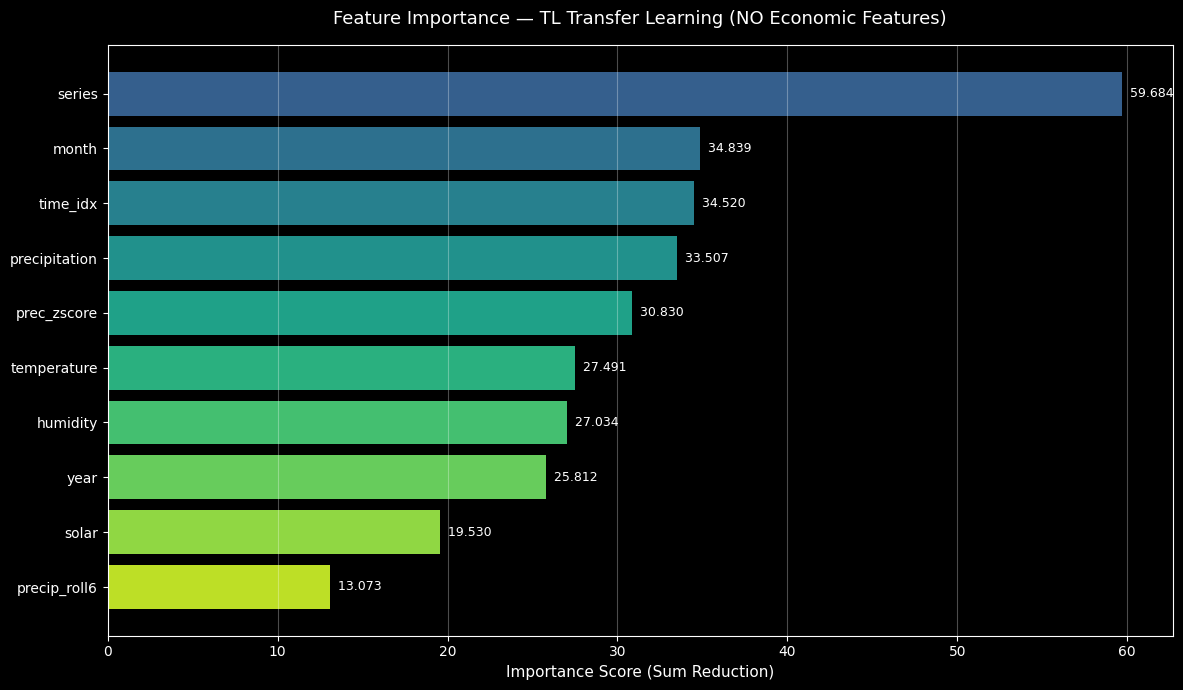


✓ Feature importance extracted and visualized successfully



In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — FEATURE IMPORTANCE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('📊 FEATURE IMPORTANCE — Transfer Learning (NO Economic Features)\n')

# Interpret model predictions
interpretation = best_model.interpret_output(raw_preds.output, reduction='sum')

# Extract encoder variable importance
enc_importance = interpretation.get('encoder_variables')
if enc_importance is not None:
    # Convert tensor to numpy
    if hasattr(enc_importance, 'detach'):
        enc_vals = enc_importance.detach().cpu().numpy()
    else:
        enc_vals = np.asarray(enc_importance)
    
    # Handle multi-dimensional case by reshaping
    if enc_vals.ndim > 1:
        enc_vals = np.abs(enc_vals).reshape(-1, enc_vals.shape[-1]).mean(axis=0)
    else:
        enc_vals = np.abs(enc_vals)
    
    # Get all feature names in order
    known_reals = list(training_vn.time_varying_known_reals)
    unknown_reals = list(training_vn.time_varying_unknown_reals)
    known_cats = list(training_vn.time_varying_known_categoricals)
    
    all_features = known_reals + unknown_reals + known_cats
    
    # Handle mismatch: if importance has fewer or more values, pad or truncate
    if len(enc_vals) != len(all_features):
        # Take only as many importance scores as we have features
        enc_vals_aligned = enc_vals[:len(all_features)] if len(enc_vals) > len(all_features) else np.pad(enc_vals, (0, len(all_features) - len(enc_vals)), mode='constant')
        print(f'  Aligned importance from {len(enc_vals)} to {len(all_features)} features')
    else:
        enc_vals_aligned = enc_vals
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': enc_vals_aligned
    }).sort_values('Importance', ascending=False)
    
    print('Top 15 Most Important Encoder Variables:')
    print('─' * 60)
    for idx, (feat, imp) in enumerate(importance_df.head(15).values, 1):
        pct = (imp / importance_df['Importance'].sum() * 100) if importance_df['Importance'].sum() > 0 else 0
        bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
        print(f'{idx:2d}. {feat:<30} {bar} {pct:>5.2f}%')
    
    # Visualize top 15
    fig, ax = plt.subplots(figsize=(12, 7))
    top_15 = importance_df.head(15)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15)))
    
    bars = ax.barh(range(len(top_15)), top_15['Importance'].values, color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'].values, fontsize=10)
    ax.set_xlabel('Importance Score (Sum Reduction)', fontsize=11)
    ax.set_title('Feature Importance — TL Transfer Learning (NO Economic Features)', fontsize=13, pad=15)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (feat, val) in enumerate(zip(top_15['Feature'].values, top_15['Importance'].values)):
        ax.text(val, i, f'  {val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print('\n✓ Feature importance extracted and visualized successfully')
else:
    print('⚠ Encoder variable importance not found in interpretation')

print()
